<a href="https://colab.research.google.com/github/matthewhawksby/colabnotebooks/blob/main/Localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne
import os
import sys
import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt
import glob
from pathlib import Path


from google.colab import drive
drive.mount('/content/drive')

import helper
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/data/"
TSV_PATH = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/stimuli/demo/*.tsv"
SRC_DIR = "/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src"
sys.path.append(SRC_DIR)

import helper
import importlib
importlib.reload(helper)

subjects_dir = Path("/content/drive/MyDrive/fsaverage")
mne.datasets.fetch_fsaverage(subjects_dir=subjects_dir, verbose=True)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 50.8 MB/s eta 0:00:00
Mounted at /content/drive
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
0 files missing from root.txt in /content/drive/MyDrive/fsaverage
0 files missing from bem.txt in /content/drive/MyDrive/fsaverage/fsaverage


PosixPath('/content/drive/MyDrive/fsaverage/fsaverage')

In [2]:


def load_all_csvs(csv_dir="/content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/data"):
    print(f"📁 Searching in directory: {csv_dir}")

    csv_files = sorted(glob.glob(os.path.join(csv_dir, "M0*_main_*.csv")))
    print(f"🔍 Found {len(csv_files)} CSV files matching 'M0*_main_*.csv'")

    if not csv_files:
        print("⚠️ No files found. Double-check the directory and filename pattern.")

    # Group files by participant
    participant_files = {}
    for path in csv_files:
        filename = os.path.basename(path)
        participant = filename.split("_")[0]
        if participant not in participant_files:
            participant_files[participant] = []
        participant_files[participant].append(path)

    # Only keep the most recent file per participant
    df_map = {}
    for participant, paths in participant_files.items():
        latest_path = sorted(paths)[-1]  # last file alphabetically is the newest
        print(f"📄 Using latest file for {participant}: {os.path.basename(latest_path)}")
        try:
            df = pd.read_csv(latest_path)
            print(f"   ✅ Loaded with shape: {df.shape}")
            df_map[participant] = df
        except Exception as e:
            print(f"   ❌ Failed to read {latest_path}: {e}")

    print("✅ Done loading most recent CSV for each participant.\n")
    return df_map

csv_data = load_all_csvs()

📁 Searching in directory: /content/drive/MyDrive/Colab Notebooks/MNE/bci-main/src/data
🔍 Found 6 CSV files matching 'M0*_main_*.csv'
📄 Using latest file for M001: M001_main_2025-04-04_14h50.48.761.csv
   ✅ Loaded with shape: (658, 65)
📄 Using latest file for M002: M002_main_2025-04-14_13h48.34.684.csv
   ✅ Loaded with shape: (658, 61)
📄 Using latest file for M003: M003_main_2025-04-14_15h02.26.451.csv
   ✅ Loaded with shape: (657, 61)
✅ Done loading most recent CSV for each participant.



In [3]:
### Why does M001 have more columns?
# Print shape of each participant's DataFrame
for participant, df in csv_data.items():
    print(f"\n📄 Participant: {participant}")
    print(f"   🔢 Shape: {df.shape}")
    print(f"   📋 Columns: {list(df.columns)}")

# Compare column names across all participant DataFrames
def compare_column_names(csv_data):
    print("\n🧮 Comparing column names across participants...")

    participant_cols = {p: set(df.columns) for p, df in csv_data.items()}

    # Print column counts and names
    for p, cols in participant_cols.items():
        print(f"\n👤 {p}: {len(cols)} columns")
        print(f"   ➤ Columns: {sorted(cols)}")

    print("\n🔍 Unique column differences:")

    participants = list(participant_cols.keys())
    for i in range(len(participants)):
        for j in range(i + 1, len(participants)):
            p1, p2 = participants[i], participants[j]
            only_in_p1 = participant_cols[p1] - participant_cols[p2]
            only_in_p2 = participant_cols[p2] - participant_cols[p1]

            if only_in_p1 or only_in_p2:
                print(f"\n🔺 {p1} vs {p2}:")
                if only_in_p1:
                    print(f"  - Only in {p1}: {sorted(only_in_p1)}")
                if only_in_p2:
                    print(f"  - Only in {p2}: {sorted(only_in_p2)}")
            else:
                print(f"\n✅ {p1} and {p2} have identical columns.")

compare_column_names(csv_data)



📄 Participant: M001
   🔢 Shape: (658, 65)
   📋 Columns: ['thisN', 'thisTrialN', 'thisRepN', 'key_resp.keys', 'buttonBox_2.keys', 'buttonBox_2.rt', 'buttonBox_2.duration', 'key_resp_3.keys', 'key_resp.rt', 'key_resp.duration', 'key_resp_3.rt', 'key_resp_3.duration', 'trials.thisRepN', 'trials.thisTrialN', 'trials.thisN', 'trials.thisIndex', 'thisRow.t', 'notes', 'intro.started', 'text.started', 'key_resp_2.started', 'intro.stopped', 'key_resp_2.keys', 'key_resp_2.rt', 'key_resp_2.duration', 'audio_file', 'presentation.started', 'trigger_sent_on.started', 'sound_1.started', 'image_2.started', 'trigger_sent_on.stopped', 'trigger_word_on.started', 'trigger_word_on.stopped', 'sound_1.stopped', 'trigger_sent_off.started', 'trigger_sent_off.stopped', 'image_2.stopped', 'presentation.stopped', 'response.started', 'key_resp.started', 'image_3.started', 'response.stopped', 'trials.key_resp.keys', 'trials.buttonBox_2.keys', 'trials.buttonBox_2.rt', 'trials.buttonBox_2.duration', 'intermission.st

In [2]:
def load_meg_blocks(participant_id, base_path="/content/drive/MyDrive/Colab Notebooks/MNE/MNE_data"):
    print(f"\n📦 Loading MEG blocks for participant: {participant_id}")

    # Construct path to participant’s data
    subfolder = f"m_{participant_id[1:]}"  # e.g., M001 → m_001
    block_path = os.path.join(base_path, subfolder, "250414")
    print(f"📁 Looking in folder: {block_path}")

    # Find all .fif block files
    fif_files = sorted(glob.glob(os.path.join(block_path, f"{participant_id}_block*_raw.fif")))
    print(f"🔍 Found {len(fif_files)} .fif files")

    if not fif_files:
        raise FileNotFoundError(f"❌ No .fif files found for {participant_id} in {block_path}")

    # Load each raw file
    raws = []
    for f in fif_files:
        print(f"📄 Reading file: {os.path.basename(f)}")
        raw = mne.io.read_raw_fif(f, preload=True, verbose=False)
        raw = raw.copy().notch_filter(freqs=[60])
        print(f"   ✅ Loaded: {raw.info['nchan']} channels, {raw.n_times} time points")
        raws.append(raw)

    # Align dev_head_t across files for safe concatenation
    print("🔧 Aligning dev_head_t across raw files...")
    for raw in raws[1:]:
        raw.info['dev_head_t'] = raws[0].info['dev_head_t']

    # Concatenate all blocks
    print("🔗 Concatenating all blocks...")
    raw_combined = mne.concatenate_raws(raws, preload=True)
    print(f"✅ Combined raw shape: {raw_combined.info['nchan']} channels, {raw_combined.n_times} time points")

    return raw_combined

raw_M001 = load_meg_blocks("M001")
raw_M001 = raw_M001.notch_filter(freqs=np.arange(60, 241, 60))  # Remove 60, 120, 180, 240 Hz harmonics





📦 Loading MEG blocks for participant: M001


NameError: name 'os' is not defined

In [6]:
def get_stg_channels(raw, top_n_per_hemi=15):
    """
    Returns the top MEG sensors most sensitive to both LH and RH Superior Temporal Gyrus (STG),
    selecting top N per hemisphere based on forward model gain strength.
    """
    import numpy as np
    import os

    print("🌐 Fetching fsaverage directory...")
    fsaverage_path = mne.datasets.fetch_fsaverage(verbose=True)
    subjects_dir = os.path.dirname(fsaverage_path)
    subject = "fsaverage"
    print(f"📁 subjects_dir: {subjects_dir}")

    # Paths
    bem_path = os.path.join(subjects_dir, subject, "bem", f"{subject}-5120-5120-5120-bem-sol.fif")
    trans_path = os.path.join(subjects_dir, subject, "bem", f"{subject}-trans.fif")

    print("🧠 Setting up fsaverage source space...")
    src = mne.setup_source_space(subject, spacing='oct6',
                                 subjects_dir=subjects_dir, add_dist=False, verbose=False)

    print("🧱 Building forward model...")
    fwd = mne.make_forward_solution(info=raw.info,
                                    trans=trans_path,
                                    src=src,
                                    bem=bem_path,
                                    meg=True, eeg=False,
                                    verbose=False)

    print("🔎 Reading STG labels from aparc atlas...")
    labels = mne.read_labels_from_annot(subject=subject,
                                        parc='aparc',
                                        subjects_dir=subjects_dir)

    lh_stg = [lbl for lbl in labels if 'superiortemporal' in lbl.name and lbl.hemi == 'lh'][0]
    rh_stg = [lbl for lbl in labels if 'superiortemporal' in lbl.name and lbl.hemi == 'rh'][0]

    print(f"   ✅ LH: {lh_stg.name} with {len(lh_stg.vertices)} vertices")
    print(f"   ✅ RH: {rh_stg.name} with {len(rh_stg.vertices)} vertices")

    def top_sensors_by_label(label, fwd, top_n):
        print(f"🔧 Restricting forward model to {label.name}...")
        fwd_sub = mne.forward.restrict_forward_to_label(fwd, label)
        G = fwd_sub['sol']['data']
        G_norm = np.linalg.norm(G.reshape(G.shape[0], -1, 3), axis=2)
        gain = np.sum(G_norm, axis=1)

        ch_names = np.array(fwd_sub['sol']['row_names'])
        top_idx = np.argsort(gain)[-top_n:][::-1]
        top = ch_names[top_idx]
        print(f"   🎯 Top {top_n} sensors for {label.name}:")
        for i, name in enumerate(top):
            print(f"     {i+1:2d}: {name} (gain={gain[top_idx[i]]:.2e})")
        return set(top)

    lh_top = top_sensors_by_label(lh_stg, fwd, top_n_per_hemi)
    rh_top = top_sensors_by_label(rh_stg, fwd, top_n_per_hemi)

    combined = sorted(lh_top.union(rh_top))
    print(f"\n🎧 Total unique STG-related sensors (LH+RH): {len(combined)}")
    return combined


stg_channels = get_stg_channels(raw_M001)
print("🎯 STG Channels selected:", stg_channels)
print(f"🔢 Total: {len(stg_channels)} channels")



🌐 Fetching fsaverage directory...
0 files missing from root.txt in /content/drive/MyDrive/fsaverage
0 files missing from bem.txt in /content/drive/MyDrive/fsaverage/fsaverage
📁 subjects_dir: /content/drive/MyDrive/fsaverage
🧠 Setting up fsaverage source space...
🧱 Building forward model...
🔎 Reading STG labels from aparc atlas...
Reading labels from parcellation...
   read 35 labels from /content/drive/MyDrive/fsaverage/fsaverage/label/lh.aparc.annot
   read 34 labels from /content/drive/MyDrive/fsaverage/fsaverage/label/rh.aparc.annot
   ✅ LH: superiortemporal-lh with 7271 vertices
   ✅ RH: superiortemporal-rh with 6868 vertices
🔧 Restricting forward model to superiortemporal-lh...
   🎯 Top 15 sensors for superiortemporal-lh:
      1: MEG1512 (gain=6.24e-02)
      2: MEG1513 (gain=6.04e-02)
      3: MEG0132 (gain=6.01e-02)
      4: MEG0242 (gain=5.03e-02)
      5: MEG0133 (gain=4.75e-02)
      6: MEG1522 (gain=4.30e-02)
      7: MEG1613 (gain=4.16e-02)
      8: MEG0243 (gain=3.64e-02)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


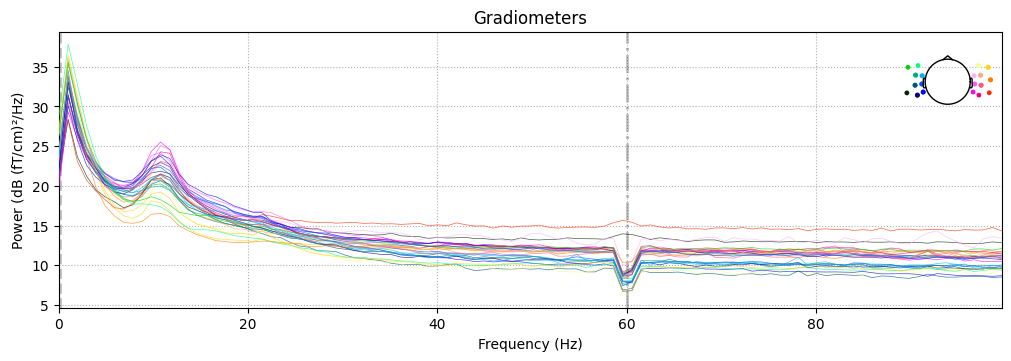

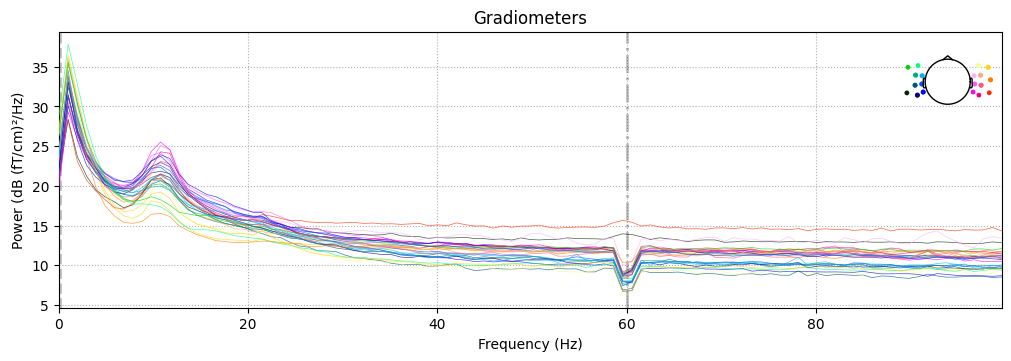

In [7]:
raw_M001.plot_psd(picks=stg_channels, fmax=100)


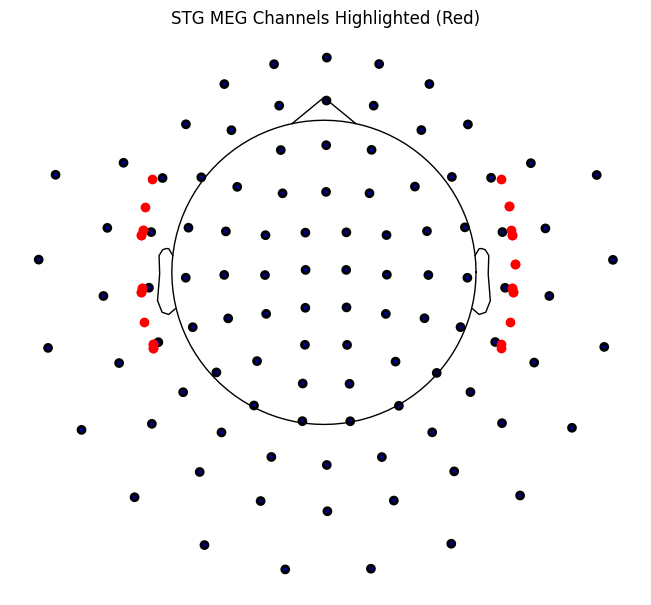

In [8]:
def plot_stg_sensor_topomap(raw, stg_channels):
    """
    Plots all MEG sensor positions and highlights STG-related ones in red.
    Works with all MNE versions (avoids private APIs).
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Base plot
    fig = raw.plot_sensors(kind='topomap', show=False)
    ax = fig.gca()

    # Get 2D positions using MNE layout
    layout = mne.channels.make_standard_montage('biosemi64')  # placeholder fallback
    try:
        layout = mne.channels.make_eeg_layout(raw.info)
    except Exception:
        pass

    # Manual fallback using loc[:2]
    for ch in raw.info['chs']:
        if ch['ch_name'] in stg_channels:
            loc = ch['loc'][:2]
            if np.all(np.isfinite(loc)):
                ax.plot(loc[0], loc[1], 'ro', markersize=6)

    plt.title("STG MEG Channels Highlighted (Red)")
    plt.show()






plot_stg_sensor_topomap(raw_M001, stg_channels)

In [1]:
def compare_hearing_vs_silent_with_options(raw, df, stg_channels=None, pre=3, post=3.0):
    """
    Compare MEG activity during sound vs silence using both filtered and unfiltered data.
    If stg_channels is provided, restrict comparison to those channels.
    """
    results = {}

    for filtered in [False, True]:
        label = "Filtered (1-40Hz)" if filtered else "Unfiltered"
        print(f"\n🔍 Processing: {label}")

        # Copy and optionally filter
        proc_raw = raw.copy()
        if filtered:
          raw_filt = raw.copy().filter(1., 40., fir_design='firwin', skip_by_annotation='edge')


        # Extract valid onsets
        onsets = df['sound_1.started'].dropna().values
        durations = [post] * len(onsets)
        descs = ['hearing'] * len(onsets)

        # Annotate and convert to events
        annots = mne.Annotations(onset=onsets, duration=durations, description=descs)
        proc_raw.set_annotations(annots)
        events, event_id = mne.events_from_annotations(proc_raw)

        # Epoch around hearing windows
        epochs = mne.Epochs(proc_raw, events, event_id=event_id,
                            tmin=-pre, tmax=post, baseline=None, preload=True, verbose=False)

        if stg_channels:
            epochs.pick_channels(stg_channels)
        else:
            epochs.pick_types(meg=True)

        # Get data and compute RMS per epoch
        data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
        rms_per_epoch = np.sqrt(np.square(data).mean(axis=1))  # shape: (n_epochs, n_times)
        avg_rms = rms_per_epoch.mean(axis=0)

        results[label] = (epochs.times, avg_rms)

    # --- Plot both
    plt.figure(figsize=(10, 4))
    for label, (times, avg_rms) in results.items():
        plt.plot(times, avg_rms, label=label)

    plt.axvline(0, linestyle='--', color='black', label='Sound Onset')
    plt.xlabel("Time (s)")
    plt.ylabel("RMS Activity (a.u.)")
    plt.title("STG MEG Activity (Hearing Epochs)")
    plt.legend()
    plt.grid()
    plt.show()

    return results

results = compare_hearing_vs_silent_with_options(raw_M001, csv_data["M001"], stg_channels)


NameError: name 'raw_M001' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Extract epochs manually for one trial
t0 = df['sound_1.started'].dropna().values[0]
tmin, tmax = -.5, .5
sfreq = raw_M001.info['sfreq']
start = int((t0 + tmin) * sfreq)
stop = int((t0 + tmax) * sfreq)
data, _ = raw_M001.get_data(picks=stg_channels, start=start, stop=stop, return_times=True)

# Plot RMS of one trial
rms = np.sqrt(np.mean(data**2, axis=0))
plt.plot(np.linspace(tmin, tmax, len(rms)), rms)
plt.axvline(0, linestyle='--', color='black', label="Sound Onset")
plt.title("STG RMS - Single Trial")
plt.xlabel("Time (s)")
plt.ylabel("RMS Activity")
plt.legend()
plt.show()


In [ ]:
pre_window = (-1.5, 0.0)   # 1s before onset
post_window = (0.0, 1.5)   # 1s after onset
times = np.linspace(tmin, tmax, len(rms))
pre_mask = (times >= pre_window[0]) & (times < pre_window[1])
post_mask = (times >= post_window[0]) & (times < post_window[1])

pre_rms = rms[pre_mask]
post_rms = rms[post_mask]
import numpy as np
from scipy.stats import ttest_rel

pre_mean = np.mean(pre_rms)
post_mean = np.mean(post_rms)

print(f"📊 Mean RMS before: {pre_mean:.2e}")
print(f"📊 Mean RMS after:  {post_mean:.2e}")

# Paired t-test
t_stat, p_val = ttest_rel(post_rms, pre_rms)
print(f"🧪 Paired t-test: t = {t_stat:.3f}, p = {p_val:.3g}")

import matplotlib.pyplot as plt

plt.hist(pre_rms, bins=50, alpha=0.5, label="Before")
plt.hist(post_rms, bins=50, alpha=0.5, label="After")
plt.legend()
plt.xlabel("RMS Activity")
plt.title("RMS Distribution Pre vs Post Sound")
plt.grid(True)
plt.show()
plt.plot(times, rms - np.mean(pre_rms))
plt.axvline(0, color='black', linestyle='--')
plt.title("RMS Minus Pre-stimulus Mean")
plt.xlabel("Time (s)")
plt.ylabel("ΔRMS")
plt.grid(True)
plt.show()



In [142]:
print("Filtered RMS max:", results["Filtered (1-40Hz)"][1].max())
print("Unfiltered RMS max:", results["Unfiltered"][1].max())
print("Epoch count (filtered):", len(results["Filtered (1-40Hz)"][1]))
print("Epoch count (unfiltered):", len(results["Unfiltered"][1]))
print("Channels in STG list (first 5):", stg_channels[:5])
print("Matching channels in raw:", [ch for ch in stg_channels if ch in raw.info['ch_names']])



Filtered RMS max: 4.0241176720193516e-10
Unfiltered RMS max: 4.0241176720193516e-10
Epoch count (filtered): 3001
Epoch count (unfiltered): 3001
Channels in STG list (first 5): [np.str_('MEG0113'), np.str_('MEG0122'), np.str_('MEG0132'), np.str_('MEG0133'), np.str_('MEG0212')]
Matching channels in raw: [np.str_('MEG0113'), np.str_('MEG0122'), np.str_('MEG0132'), np.str_('MEG0133'), np.str_('MEG0212'), np.str_('MEG0213'), np.str_('MEG0242'), np.str_('MEG0243'), np.str_('MEG1322'), np.str_('MEG1332'), np.str_('MEG1333'), np.str_('MEG1412'), np.str_('MEG1422'), np.str_('MEG1423'), np.str_('MEG1432'), np.str_('MEG1433'), np.str_('MEG1442'), np.str_('MEG1443'), np.str_('MEG1512'), np.str_('MEG1513'), np.str_('MEG1522'), np.str_('MEG1523'), np.str_('MEG1543'), np.str_('MEG1612'), np.str_('MEG1613'), np.str_('MEG2423'), np.str_('MEG2612'), np.str_('MEG2613'), np.str_('MEG2623'), np.str_('MEG2642')]


In [153]:
print(raw_M001.annotations)
print(set(raw_M001.annotations.description))


<Annotations | 14 segments: BAD boundary (7), EDGE boundary (7)>
{np.str_('EDGE boundary'), np.str_('BAD boundary')}


In [2]:

def analyze_auditory_evoked_response(raw, events, event_id, stg_channels, tmin=-3.0, max=3.0):
    """
    Plot auditory evoked response from STG channels.
    """
    print(f"⏱ Epoch window: {tmin} to {tmax} seconds")
    # Create epochs
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=(None, 0),
        picks=stg_channels,
        preload=True
    )

    # Average across trials
    evoked = epochs.average()
        # Plot each STG channel separately over time
    times = evoked.times
    stg_data = evoked.copy().pick_channels(stg_channels).data * 1e15  # Convert to fT

    fig, axes = plt.subplots(len(stg_channels), 1, figsize=(10, 2 * len(stg_channels)), sharex=True)
    fig.suptitle("STG Channel Time Series (Evoked)", fontsize=16)

    for i, ch in enumerate(stg_channels):
        axes[i].plot(times, stg_data[i])
        axes[i].axvline(0, linestyle='--', color='black', label='Sound Onset' if i == 0 else "")
        axes[i].set_ylabel(ch)
        axes[i].grid(True)
        if i == 0:
            axes[i].legend()

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()


    # Plot joint response with topomaps
    evoked.plot_joint(
        title="Auditory Evoked Response (STG Channels)",
        times=[0.0, 0.1, 0.2, 0.3, 0.5]  # customize as needed
    )
    evoked.plot_joint(times=[0.0, 0.1, 0.15, 0.2], title="M100 Response (STG Channels)")
    evoked.plot(picks='grad', spatial_colors=True, titles='STG Gradiometers', time_unit='s')

    return evoked

df_M001 = csv_data['M001']

onsets = df_M001['sound_1.started'].dropna().values
durations = [1.0] * len(onsets)
descriptions = ['hearing'] * len(onsets)

annotations = mne.Annotations(onset=onsets, duration=durations, description=descriptions)
raw_M001.set_annotations(annotations)


# Step 1: Get events and event_id from annotations
events, event_id = mne.events_from_annotations(raw_M001, event_id={'hearing': 1})


# Step 2: Run analysis
evoked = analyze_auditory_evoked_response(raw_M001, events,  event_id, stg_channels)



stc = mne.minimum_norm.apply_inverse(evoked, inverse_operator, lambda2=1.0 / snr**2, method='dSPM')
brain = stc.plot(subject='fsaverage', subjects_dir=subjects_dir, initial_time=0.1)
evoked.plot_topomap(times=[0.1], ch_type='grad', title='M100 Topomap')
evoked.plot_joint(title="Auditory Evoked Response", times=[0.0, 0.1, 0.2, 0.4, 0.6])
evoked.plot(picks='grad', titles="Gradiometers", time_unit='s', spatial_colors=True, xlim=(-0.2, 0.8))

# Find peak between 70 and 130 ms
peak_time = evoked.get_peak(tmin=0.07, tmax=0.13, mode='abs')[1]
print(f"⚡ M100 Peak at: {peak_time:.3f} s")

evoked.plot_joint(times=[peak_time], title="Detected M100 Peak (STG Channels)")





NameError: name 'csv_data' is not defined

Applying baseline correction (mode: mean)
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 6601 samples (3.300 s)



<ipython-input-156-da6e0ddd137e>:3: RuntimeWarning: filter_length (6601) is longer than the signal (1401), distortion is likely. Reduce filter length or filter a longer signal.
  evoked = evoked.copy().filter(1., 40., fir_design='firwin')  # Bandpass filter
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


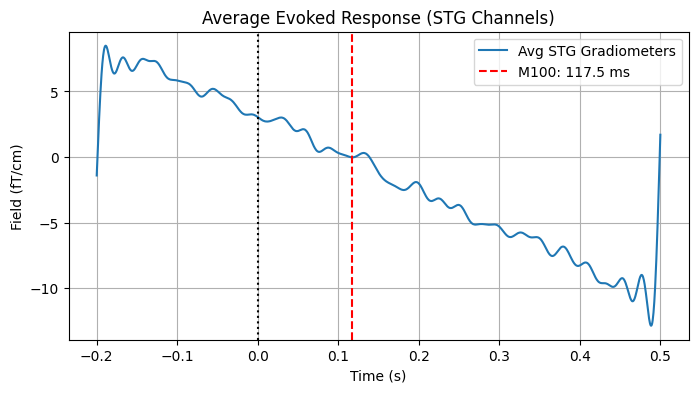

In [156]:
# --- Baseline correct (use same evoked object, assume tmin = -0.2s)
evoked = evoked.copy().apply_baseline(baseline=(-0.2, 0.0))  # Baseline correction
evoked = evoked.copy().filter(1., 40., fir_design='firwin')  # Bandpass filter

# --- Now average over channels
mean_waveform = evoked.data.mean(axis=0)
times = evoked.times

# --- Find minimum between 70-130 ms
m100_window = (times >= 0.07) & (times <= 0.13)
m100_time = times[m100_window][mean_waveform[m100_window].argmin()]
m100_amp = mean_waveform[m100_window].min()

# --- Plot
plt.figure(figsize=(8,4))
plt.plot(times, mean_waveform * 1e13, label='Avg STG Gradiometers')  # fT/cm
plt.axvline(m100_time, color='red', linestyle='--', label=f"M100: {m100_time*1000:.1f} ms")
plt.axvline(0, color='black', linestyle=':')
plt.xlabel("Time (s)")
plt.ylabel("Field (fT/cm)")
plt.title("Average Evoked Response (STG Channels)")
plt.legend()
plt.grid()
plt.show()


In [26]:
def print_sample_meg_values(raw, df, n_samples=3, duration_sec=0.2):
    # Pick only MEG channels
    picks = mne.pick_types(raw.info, meg=True)

    sfreq = raw.info['sfreq']
    duration = int(duration_sec * sfreq)

    print("\n🎧 Sample HEARING segments (MEG only):")
    hearing_trials = df[df['sound_1.started'] > 0].sample(n=n_samples)
    for i, row in hearing_trials.iterrows():
        start = int(row['sound_1.started'] * sfreq)
        stop = start + duration
        segment, _ = raw[picks, start:stop]
        print(f"Trial {i} - shape: {segment.shape}, values:\n{segment[:, :5]}")
        print("  Max value:", np.max(segment) if segment.size > 0 else "N/A")

    print("\n🤫 Sample SILENT segments (MEG only):")
    for i, row in hearing_trials.iterrows():
        start = int((row['sound_1.started'] - 0.5) * sfreq)
        if start < 0:
            continue
        stop = start + duration
        segment, _ = raw[picks, start:stop]
        print(f"Trial {i} - shape: {segment.shape}, values:\n{segment[:, :5]}")
        print("  Max value:", np.max(segment) if segment.size > 0 else "N/A")
        print("  Avg value:", np.mean(segment) if segment.size > 0 else "N/A")
        print(f"  Onset={row['sound_1.started']}, start={start}, stop={stop}, raw.n_times={raw.n_times}")





In [28]:
def compute_segment_averages(raw, df, duration_sec=0.2):
    picks = mne.pick_types(raw.info, meg=True)
    sfreq = raw.info['sfreq']
    duration = int(duration_sec * sfreq)

    hearing_segments = []
    silent_segments = []

    for _, row in df[df['sound_1.started'] > 0].iterrows():
        # Hearing segment
        start = int(row['sound_1.started'] * sfreq)
        stop = start + duration
        if stop <= raw.n_times:
            segment, _ = raw[picks, start:stop]
            hearing_segments.append(segment)

        # Silent segment
        silent_start = int((row['sound_1.started'] - 0.5) * sfreq)
        silent_stop = silent_start + duration
        if silent_start >= 0 and silent_stop <= raw.n_times:
            silent_segment, _ = raw[picks, silent_start:silent_stop]
            silent_segments.append(silent_segment)

    # Combine all segments into one array each
    hearing_all = np.concatenate(hearing_segments, axis=1) if hearing_segments else np.array([])
    silent_all = np.concatenate(silent_segments, axis=1) if silent_segments else np.array([])

    print("\n📊 Overall Averages:")
    print("  Hearing segments avg:", np.mean(hearing_all) if hearing_all.size > 0 else "N/A")
    print("  Silent segments avg:", np.mean(silent_all) if silent_all.size > 0 else "N/A")


In [29]:
for pid in ['M001', 'M002', 'M003']:
    print(f"\n🔎 Participant {pid}")
    raw = load_meg_blocks(pid)
    df = csv_data[pid]
    compute_segment_averages(raw, df)
    print_sample_meg_values(raw, df)
    print("→ Running with ALL sensors")

    #compare_hearing_vs_silence(raw, df)

    # Optional: Use auditory (STG) subset
    try:
        stg_channels = get_stg_channels(raw, subjects_dir="/content/drive/MyDrive/fsaverage")
        print(f"→ Running with STG sensors ({len(stg_channels)})")
        compare_hearing_vs_silence(raw, df, channels=stg_channels)
    except:
        print("⚠️ Could not isolate STG sensors — skipping subset")




🔎 Participant M001

📊 Overall Averages:
  Hearing segments avg: 1.117126750911875e-14
  Silent segments avg: 1.1825629380242398e-13

🎧 Sample HEARING segments (MEG only):
Trial 59 - shape: (306, 400), values:
[[-1.15144157e-11 -1.20648956e-11 -1.12886429e-11 -9.92132186e-12
  -9.17297363e-12]
 [ 4.67948912e-11  5.33660887e-11  2.62847900e-11 -5.37643431e-12
  -3.16612243e-11]
 [-3.28559875e-11 -2.19039916e-11 -1.45362854e-11 -2.09083557e-11
  -1.75231933e-11]
 ...
 [ 8.29524993e-12  8.11006545e-12  6.22270584e-12  4.66259002e-12
   4.68542099e-12]
 [-8.14430235e-11 -1.00957489e-10 -2.64839172e-11  6.39198302e-11
   1.15692901e-10]
 [-5.09765624e-11 -6.59111021e-11 -1.65275573e-11  5.85433959e-11
   9.53819273e-11]]
  Max value: 3.4261825481549817e-09
Trial 161 - shape: (306, 400), values:
[[ 1.49821854e-11  1.98223495e-11  2.15651131e-11  1.87569046e-11
   1.41272926e-11]
 [ 1.73240661e-11 -4.57992553e-12 -1.47354126e-11 -4.18167113e-12
   9.35897825e-12]
 [-8.76159666e-12 -2.66830444